In [54]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

## Open Scan files

In [55]:
GAMBIT_RANDOM = "FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "FS_MSSM7atQ_diver_gm2_gambit.hdf5"
# GAMBIT_DIVER = "FS_MSSM7atQ_diver_relicd_gambit.hdf5"
MODELGEN = "SP_MSSM7atQ_random_modelgen.hdf5"
VERSION = 12

def open_scan(file_name: str, version: str = VERSION) -> h5py.File:
    """open a scan file and return the h5py File object"""
    file_path = f"../data/version-{version}/{file_name}"

    return h5py.File(file_path, "r")["MSSM"]

scan_modelgen = open_scan(MODELGEN)
scan_gambit_random = open_scan(GAMBIT_RANDOM)
scan_gambit_diver = open_scan(GAMBIT_DIVER)

## Select Parameter

In [56]:
def parameter_lookup(parameter: str, conversion_table: str = "conversion_table.txt") -> str:
    """
    For any givern parameter look up its counterpart (GAMBIT <-> MODELGEN) in the conversion table.
    If the parameter is not found ask the user for the counterpart and add it to the table.

    returns: str (gambit-parameter;modelgen-parameter)
    """
    parameter_type = "gambit" if len(parameter.split(" ")) > 1 else "modelgen"

    def add_conversion_entry():
        if parameter_type == "gambit":
            gambit_par = parameter
            modelgen_par = input(f"enter the corresponding MODELGEN parameter name for {parameter}").strip()
        if parameter_type == "modelgen":
            gambit_par = input(f"enter the corresponding GAMBIT parameter name for {parameter}").strip()
            modelgen_par = parameter
        parameter_pair = "\n" + gambit_par + ";" + modelgen_par
        with open(conversion_table, "a") as file:
            file.write(parameter_pair)
        return parameter_pair.strip()

    if not os.path.isfile(conversion_table):
        parameter_pair = add_conversion_entry()
        return parameter_pair

    with open(conversion_table, "r") as file:
        for line in file:
            if parameter in line:
                parameter_pair = line.strip()
                return parameter_pair
            
    parameter_pair = add_conversion_entry()
    return parameter_pair
        


## Cretae Plot

In [57]:
def create_plot(parameter):

    parameter_pair = parameter_lookup(parameter).split(";")
    mask_gambit_random = scan_gambit_random[parameter_pair[0] + "_isvalid"][:] == 1
    mask_gambit_diver = scan_gambit_diver[parameter_pair[0] + "_isvalid"][:] == 1
    mask_modelgen = scan_modelgen[parameter_pair[1]][:] != -1
    data_gambit_random = scan_gambit_random[parameter_pair[0]][mask_gambit_random]
    data_gambit_diver =  scan_gambit_diver[parameter_pair[0]][mask_gambit_diver]
    data_modelgen = scan_modelgen[parameter_pair[1]][mask_modelgen]

    print("Scan          | VALID/ATTEMPTED")
    print("-------------------------------------")
    print(f"GAMBIT random | {np.sum(mask_gambit_random)}/{len(mask_gambit_random)}  {(np.sum(mask_gambit_random)/len(mask_gambit_random))*100:.2f}%")
    print(f"GAMBIT diver  | {np.sum(mask_gambit_diver)}/{len(mask_gambit_diver)}  {(np.sum(mask_gambit_diver)/len(mask_gambit_diver))*100:.2f}%")
    print(f"MODELGEN      | {np.sum(mask_modelgen)}/{len(mask_modelgen)}  {(np.sum(mask_modelgen)/len(mask_modelgen))*100:.2f}%")

    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111)
    hist_range = (
        min([np.min(data_gambit_random), np.min(data_gambit_diver), np.min(data_modelgen)]),
        max([np.max(data_gambit_random), np.max(data_gambit_diver), np.max(data_modelgen)])
        )
    
    ax.hist(data_gambit_random, bins=50, range=hist_range, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label="GAMBIT random")
    ax.hist(data_gambit_random, bins=50, range=hist_range, density=True, histtype='step', color='rebeccapurple')
    ax.hist(data_gambit_diver, bins=50, range=hist_range, density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
    ax.hist(data_gambit_diver, bins=50, range=hist_range, density=True, histtype='step', color='teal')
    ax.hist(data_modelgen, bins=50, range=hist_range, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
    ax.hist(data_modelgen, bins=50, range=hist_range, density=True, histtype='step', color='darksalmon')
    
    
    ax.set_xlabel(parameter_pair[1][parameter_pair[1].find("_")+1:])
    ax.set_ylabel("Density")
    
    # ax.set_xlim(hist_range)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.legend(frameon=False)
    
    fig.savefig(f"plots/version-{VERSION}/{parameter_pair[1][parameter_pair[1].find('_')+1:]}-version-{VERSION}.png", dpi=1000)
    
    plt.show()
    plt.close()

Scan          | VALID/ATTEMPTED
-------------------------------------
GAMBIT random | 89554/90000  99.50%
GAMBIT diver  | 6022/90000  6.69%
MODELGEN      | 1714/90000  1.90%


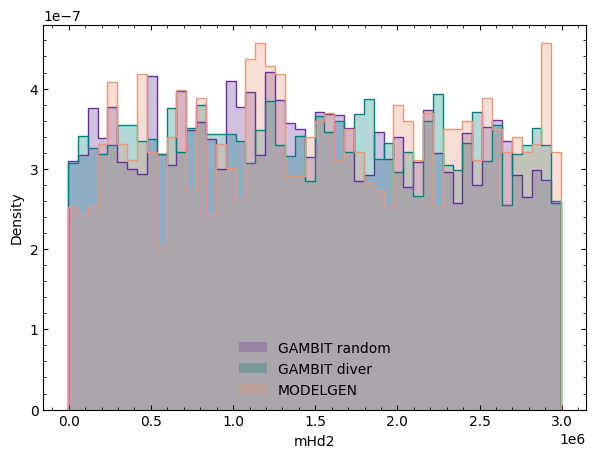

In [58]:
parameter = "#MSSM_spectrum @SpecBit::get_MSSM_spectrum_as_map::mHd2 mass2"
create_plot(parameter)

In [68]:
def plot_all(conversion_table_path: str):
    with open(conversion_table_path, 'r') as conversion_table:
        parameter_list = conversion_table.readlines()
    
    parameter_list = [par.strip().split(';')[-1] for par in parameter_list]
    for par in parameter_list: create_plot(par)

# plot_all("conversion_table.txt")

In [60]:
par1 = parameter_lookup("SP_m_h").split(";")
par2 = parameter_lookup("SP_m_A").split(";")
par3 = parameter_lookup("SP_m_H").split(";")
par4 = parameter_lookup("SP_m_Hp").split(";")

mask_gambit_random = scan_gambit_random[par1[0] + "_isvalid"][:] == 1
mask_gambit_diver = scan_gambit_diver[par1[0] + "_isvalid"][:] == 1
mask_modelgen = scan_modelgen[par1[1]][:] != -1
data_gambit_random1 = scan_gambit_random[par1[0]][mask_gambit_random]
data_gambit_diver1 =  scan_gambit_diver[par1[0]][mask_gambit_diver]
data_modelgen1 = scan_modelgen[par1[1]][mask_modelgen]
sampl_eff_gambit1 =   f"GAMBIT random \n{np.sum(mask_gambit_random)}/{len(mask_gambit_random)}  {(np.sum(mask_gambit_random)/len(mask_gambit_random))*100:.2f}%"
sampl_eff_gambit_diver1 =  f"GAMBIT diver\n{np.sum(mask_gambit_diver)}/{len(mask_gambit_diver)}  {(np.sum(mask_gambit_diver)/len(mask_gambit_diver))*100:.2f}%"
sampl_eff_modelgen1 = f"MODELGEN\n{np.sum(mask_modelgen)}/{len(mask_modelgen)}  {(np.sum(mask_modelgen)/len(mask_modelgen))*100:.2f}%"

mask_gambit_random = scan_gambit_random[par2[0] + "_isvalid"][:] == 1
mask_gambit_diver = scan_gambit_diver[par2[0] + "_isvalid"][:] == 1
mask_modelgen = scan_modelgen[par2[1]][:] != -1
data_gambit_random2 = scan_gambit_random[par2[0]][mask_gambit_random]
data_gambit_diver2 =  scan_gambit_diver[par2[0]][mask_gambit_diver]
data_modelgen2 = scan_modelgen[par2[1]][mask_modelgen]
sampl_eff_gambit2 =   f"GAMBIT    \n{np.sum(mask_gambit_random)}/{len(mask_gambit_random)}  {(np.sum(mask_gambit_random)/len(mask_gambit_random))*100:.2f}%"
sampl_eff_gambit_diver2 =  f"GAMBIT DIVER\n{np.sum(mask_gambit_diver)}/{len(mask_gambit_diver)}  {(np.sum(mask_gambit_diver)/len(mask_gambit_diver))*100:.2f}%"
sampl_eff_modelgen2 = f"MODELGEN  \n{np.sum(mask_modelgen)}/{len(mask_modelgen)}  {(np.sum(mask_modelgen)/len(mask_modelgen))*100:.2f}%"

mask_gambit_random = scan_gambit_random[par3[0] + "_isvalid"][:] == 1
mask_gambit_diver = scan_gambit_diver[par3[0] + "_isvalid"][:] == 1
mask_modelgen = scan_modelgen[par3[1]][:] != -1
data_gambit_random3 = scan_gambit_random[par3[0]][mask_gambit_random]
data_gambit_diver3 =  scan_gambit_diver[par3[0]][mask_gambit_diver]
data_modelgen3 = scan_modelgen[par3[1]][mask_modelgen]
sampl_eff_gambit3 =   f"GAMBIT    {np.sum(mask_gambit_random)}/{len(mask_gambit_random)}  {(np.sum(mask_gambit_random)/len(mask_gambit_random))*100:.2f}%"
sampl_eff_gambit_diver3 =  f"GAMBIT DIVER\n{np.sum(mask_gambit_diver)}/{len(mask_gambit_diver)}  {(np.sum(mask_gambit_diver)/len(mask_gambit_diver))*100:.2f}%"
sampl_eff_modelgen3 = f"MODELGEN  {np.sum(mask_modelgen)}/{len(mask_modelgen)}  {(np.sum(mask_modelgen)/len(mask_modelgen))*100:.2f}%"

mask_gambit_random = scan_gambit_random[par4[0] + "_isvalid"][:] == 1
mask_gambit_diver = scan_gambit_diver[par4[0] + "_isvalid"][:] == 1
mask_modelgen = scan_modelgen[par4[1]][:] != -1
data_gambit_random4 = scan_gambit_random[par4[0]][mask_gambit_random]
data_gambit_diver4 =  scan_gambit_diver[par4[0]][mask_gambit_diver]
data_modelgen4 = scan_modelgen[par4[1]][mask_modelgen]
sampl_eff_gambit4 =   f"GAMBIT    {np.sum(mask_gambit_random)}/{len(mask_gambit_random)}  {(np.sum(mask_gambit_random)/len(mask_gambit_random))*100:.2f}%"
sampl_eff_gambit_diver4 =  f"GAMBIT DIVER\n{np.sum(mask_gambit_diver)}/{len(mask_gambit_diver)}  {(np.sum(mask_gambit_diver)/len(mask_gambit_diver))*100:.2f}%"
sampl_eff_modelgen4 = f"MODELGEN  {np.sum(mask_modelgen)}/{len(mask_modelgen)}  {(np.sum(mask_modelgen)/len(mask_modelgen))*100:.2f}%"






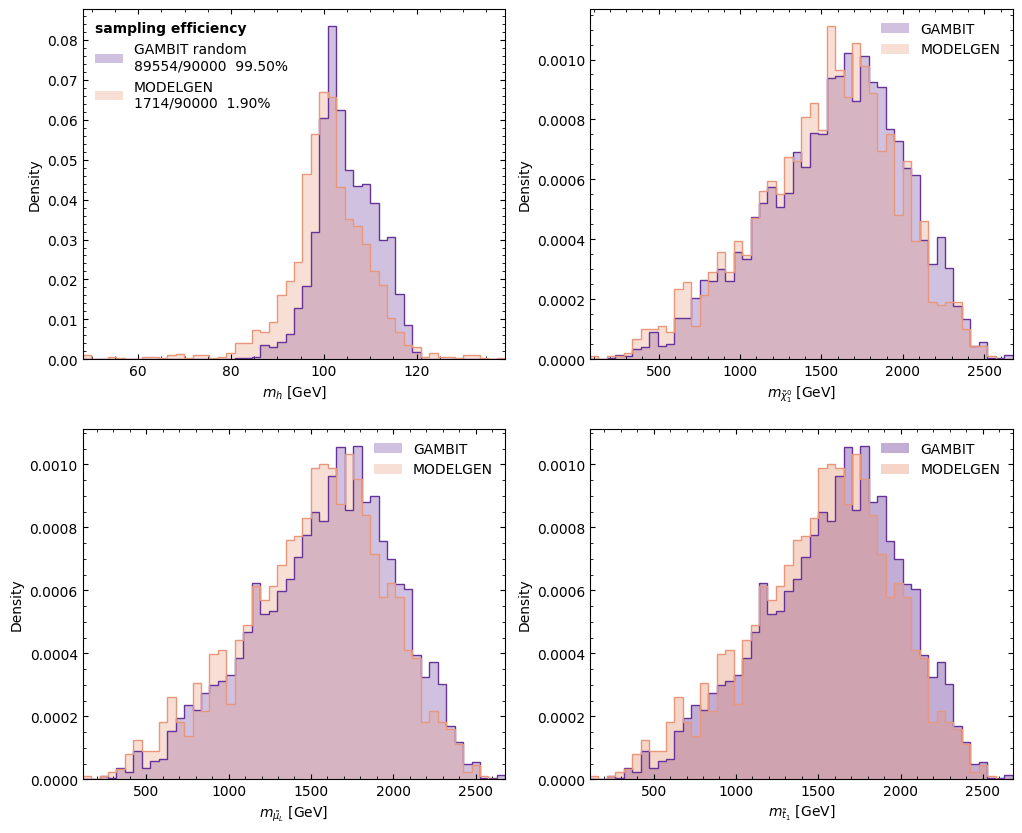

In [61]:
fig = plt.figure(figsize=(12,10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

hist_range1 = (
        min([np.min(data_gambit_random1), np.min(data_modelgen1)]),
        max([np.max(data_gambit_random1), np.max(data_modelgen1)])
        )

hist_range2 = (
        min([np.min(data_gambit_random2), np.min(data_modelgen2)]),
        max([np.max(data_gambit_random2), np.max(data_modelgen2)])
        )

hist_range3 = (
        min([np.min(data_gambit_random3), np.min(data_modelgen3)]),
        max([np.max(data_gambit_random3), np.max(data_modelgen3)])
        )

hist_range4 = (
        min([np.min(data_gambit_random4), np.min(data_modelgen4)]),
        max([np.max(data_gambit_random4), np.max(data_modelgen4)])
        )


ax1.hist(data_gambit_random1, bins=50, range=hist_range1, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label=sampl_eff_gambit1)
ax1.hist(data_gambit_random1, bins=50, range=hist_range1, density=True, histtype='step', color='rebeccapurple')
ax1.hist(data_modelgen1, bins=50, range=hist_range1, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label=sampl_eff_modelgen1)
ax1.hist(data_modelgen1, bins=50, range=hist_range1, density=True, histtype='step', color='darksalmon')
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)
leg = ax1.legend(frameon=False)
leg.set_title("sampling efficiency", prop={'weight': 'bold'})
leg._legend_box.align = "left"
ax1.set_xlim(hist_range1)
ax1.set_ylabel("Density")
ax1.set_xlabel("$m_h$ [GeV]")

ax2.hist(data_gambit_random2, bins=50, range=hist_range2, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label="GAMBIT")
ax2.hist(data_gambit_random2, bins=50, range=hist_range2, density=True, histtype='step', color='rebeccapurple')
ax2.hist(data_modelgen2, bins=50, range=hist_range2, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax2.hist(data_modelgen2, bins=50, range=hist_range2, density=True, histtype='step', color='darksalmon')
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax2.legend(frameon=False)
ax2.set_xlim(hist_range2)
ax2.set_ylabel("Density")
ax2.set_xlabel("$m_{\\tilde{\\chi}_1^0}$ [GeV]")

ax3.hist(data_gambit_random3, bins=50, range=hist_range3, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label="GAMBIT")
ax3.hist(data_gambit_random3, bins=50, range=hist_range3, density=True, histtype='step', color='rebeccapurple')
ax3.hist(data_modelgen3, bins=50, range=hist_range3, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax3.hist(data_modelgen3, bins=50, range=hist_range3, density=True, histtype='step', color='darksalmon')
ax3.minorticks_on()
ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax3.legend(frameon=False)
ax3.set_xlim(hist_range3)
ax3.set_ylabel("Density")
ax3.set_xlabel("$m_{\\tilde{\\mu}_L}$ [GeV]")

ax4.hist(data_gambit_random4, bins=50, range=hist_range4, density=True, alpha=0.4, histtype='stepfilled', color='rebeccapurple', label="GAMBIT")
ax4.hist(data_gambit_random4, bins=50, range=hist_range4, density=True, histtype='step', color='rebeccapurple')
ax4.hist(data_modelgen4, bins=50, range=hist_range4, density=True, alpha=0.4, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax4.hist(data_modelgen4, bins=50, range=hist_range4, density=True, histtype='step', color='darksalmon')
ax4.minorticks_on()
ax4.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax4.legend(frameon=False)
ax4.set_xlim(hist_range4)
ax4.set_ylabel("Density")
ax4.set_xlabel("$m_{\\tilde{t}_1}$ [GeV]")


fig.savefig(f"plots/thesis_plots/baseline_histograms.png", dpi=1000)

plt.show()

In [75]:
def create_comparison_plots(parameter_list: list, labels: list, output_path: str, title:str = ""):

        par1 = parameter_lookup(parameter_list[0]).split(";")
        par2 = parameter_lookup(parameter_list[1]).split(";")
        par3 = parameter_lookup(parameter_list[2]).split(";")
        par4 = parameter_lookup(parameter_list[3]).split(";")

        mask_gambit_random = scan_gambit_random[par1[0] + "_isvalid"][:] == 1
        mask_gambit_diver = scan_gambit_diver[par1[0] + "_isvalid"][:] == 1
        mask_modelgen = scan_modelgen[par1[1]][:] != -1
        data_gambit_random1 = scan_gambit_random[par1[0]][mask_gambit_random]
        data_gambit_diver1 =  scan_gambit_diver[par1[0]][mask_gambit_diver]
        data_modelgen1 = scan_modelgen[par1[1]][mask_modelgen]
        sampl_eff_gambit1 =   f"GAMBIT random \n{np.sum(mask_gambit_random)}/{len(mask_gambit_random)}  {(np.sum(mask_gambit_random)/len(mask_gambit_random))*100:.2f}%"
        sampl_eff_gambit_diver1 =  f"GAMBIT diver\n{np.sum(mask_gambit_diver)}/{len(mask_gambit_diver)}  {(np.sum(mask_gambit_diver)/len(mask_gambit_diver))*100:.2f}%"
        sampl_eff_modelgen1 = f"MODELGEN\n{np.sum(mask_modelgen)}/{len(mask_modelgen)}  {(np.sum(mask_modelgen)/len(mask_modelgen))*100:.2f}%"

        mask_gambit_random = scan_gambit_random[par2[0] + "_isvalid"][:] == 1
        mask_gambit_diver = scan_gambit_diver[par2[0] + "_isvalid"][:] == 1
        mask_modelgen = scan_modelgen[par2[1]][:] != -1
        data_gambit_random2 = scan_gambit_random[par2[0]][mask_gambit_random]
        data_gambit_diver2 =  scan_gambit_diver[par2[0]][mask_gambit_diver]
        data_modelgen2 = scan_modelgen[par2[1]][mask_modelgen]
        

        mask_gambit_random = scan_gambit_random[par3[0] + "_isvalid"][:] == 1
        mask_gambit_diver = scan_gambit_diver[par3[0] + "_isvalid"][:] == 1
        mask_modelgen = scan_modelgen[par3[1]][:] != -1
        data_gambit_random3 = scan_gambit_random[par3[0]][mask_gambit_random]
        data_gambit_diver3 =  scan_gambit_diver[par3[0]][mask_gambit_diver]
        data_modelgen3 = scan_modelgen[par3[1]][mask_modelgen]
        

        mask_gambit_random = scan_gambit_random[par4[0] + "_isvalid"][:] == 1
        mask_gambit_diver = scan_gambit_diver[par4[0] + "_isvalid"][:] == 1
        mask_modelgen = scan_modelgen[par4[1]][:] != -1
        data_gambit_random4 = scan_gambit_random[par4[0]][mask_gambit_random]
        data_gambit_diver4 =  scan_gambit_diver[par4[0]][mask_gambit_diver]
        data_modelgen4 = scan_modelgen[par4[1]][mask_modelgen]
       



        fig = plt.figure(figsize=(12,10))
        ax1 = fig.add_subplot(221)
        ax2 = fig.add_subplot(222)
        ax3 = fig.add_subplot(223)
        ax4 = fig.add_subplot(224)

        hist_range1 = (
                min([np.min(data_gambit_random1), np.min(data_modelgen1), np.min(data_gambit_diver1)]),
                max([np.max(data_gambit_random1), np.max(data_modelgen1), np.max(data_gambit_diver1)])
                )

        hist_range2 = (
                min([np.min(data_gambit_random2), np.min(data_modelgen2), np.min(data_gambit_diver2)]),
                max([np.max(data_gambit_random2), np.max(data_modelgen2), np.max(data_gambit_diver2)])
                )

        hist_range3 = (
                min([np.min(data_gambit_random3), np.min(data_modelgen3), np.min(data_gambit_diver3)]),
                max([np.max(data_gambit_random3), np.max(data_modelgen3), np.max(data_gambit_diver3)])
                )

        hist_range4 = (
                min([np.min(data_gambit_random4), np.min(data_modelgen4), np.min(data_gambit_diver4)]),
                max([np.max(data_gambit_random4), np.max(data_modelgen4), np.max(data_gambit_diver4)])
                )


        ax1.hist(data_gambit_random1, bins=50, range=hist_range1, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label=sampl_eff_gambit1)
        ax1.hist(data_gambit_random1, bins=50, range=hist_range1, density=True, histtype='step', color='rebeccapurple')
        ax1.hist(data_gambit_diver1, bins=50, range=hist_range1, density=True, alpha=0.3, histtype='stepfilled', color='teal', label=sampl_eff_gambit_diver1)
        ax1.hist(data_gambit_diver1, bins=50, range=hist_range1, density=True, histtype='step', color='teal')
        ax1.hist(data_modelgen1, bins=50, range=hist_range1, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label=sampl_eff_modelgen1)
        ax1.hist(data_modelgen1, bins=50, range=hist_range1, density=True, histtype='step', color='darksalmon')
        ax1.minorticks_on()
        ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        leg = ax1.legend(frameon=False)
        leg.set_title("sampling efficiency", prop={'weight': 'bold'})
        leg._legend_box.align = "left"
        if "Neutralino" in title:
                ax1.set_xlim(hist_range1[0]-150, hist_range1[1]+50)
        else:
                ax1.set_xlim(hist_range1[0]-0, hist_range1[1])
        ax1.set_ylabel("Density")
        ax1.set_xlabel(labels[0])

        ax2.hist(data_gambit_random2, bins=50, range=hist_range2, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label="GAMBIT random")
        ax2.hist(data_gambit_random2, bins=50, range=hist_range2, density=True, histtype='step', color='rebeccapurple')
        ax2.hist(data_gambit_diver2, bins=50, range=hist_range2, density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
        ax2.hist(data_gambit_diver2, bins=50, range=hist_range2, density=True, histtype='step', color='teal')
        ax2.hist(data_modelgen2, bins=50, range=hist_range2, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
        ax2.hist(data_modelgen2, bins=50, range=hist_range2, density=True, histtype='step', color='darksalmon')
        ax2.minorticks_on()
        ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        ax2.legend(frameon=False)
        ax2.set_xlim(hist_range2)
        ax2.set_ylabel("Density")
        ax2.set_xlabel(labels[1])

        ax3.hist(data_gambit_random3, bins=50, range=hist_range3, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label="GAMBIT random")
        ax3.hist(data_gambit_random3, bins=50, range=hist_range3, density=True, histtype='step', color='rebeccapurple')
        ax3.hist(data_gambit_diver3, bins=50, range=hist_range3, density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
        ax3.hist(data_gambit_diver3, bins=50, range=hist_range3, density=True, histtype='step', color='teal')
        ax3.hist(data_modelgen3, bins=50, range=hist_range3, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
        ax3.hist(data_modelgen3, bins=50, range=hist_range3, density=True, histtype='step', color='darksalmon')
        ax3.minorticks_on()
        ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        ax3.legend(frameon=False)
        ax3.set_xlim(hist_range3)
        ax3.set_ylabel("Density")
        ax3.set_xlabel(labels[2])

        ax4.hist(data_gambit_random4, bins=50, range=hist_range4, density=True, alpha=0.4, histtype='stepfilled', color='rebeccapurple', label="GAMBIT")
        ax4.hist(data_gambit_random4, bins=50, range=hist_range4, density=True, histtype='step', color='rebeccapurple')
        ax4.hist(data_gambit_diver4, bins=50, range=hist_range4, density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
        ax4.hist(data_gambit_diver4, bins=50, range=hist_range4, density=True, histtype='step', color='teal')
        ax4.hist(data_modelgen4, bins=50, range=hist_range4, density=True, alpha=0.4, histtype='stepfilled', color='darksalmon', label="MODELGEN")
        ax4.hist(data_modelgen4, bins=50, range=hist_range4, density=True, histtype='step', color='darksalmon')
        ax4.minorticks_on()
        ax4.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        ax4.legend(frameon=False)
        ax4.set_xlim(hist_range4)
        ax4.set_ylabel("Density")
        ax4.set_xlabel(labels[3])


        if title:
                fig.suptitle(title, y=0.92, fontsize=16)
        fig.savefig(f"plots/thesis_plots/{output_path}.png", dpi=1000)

        plt.show()

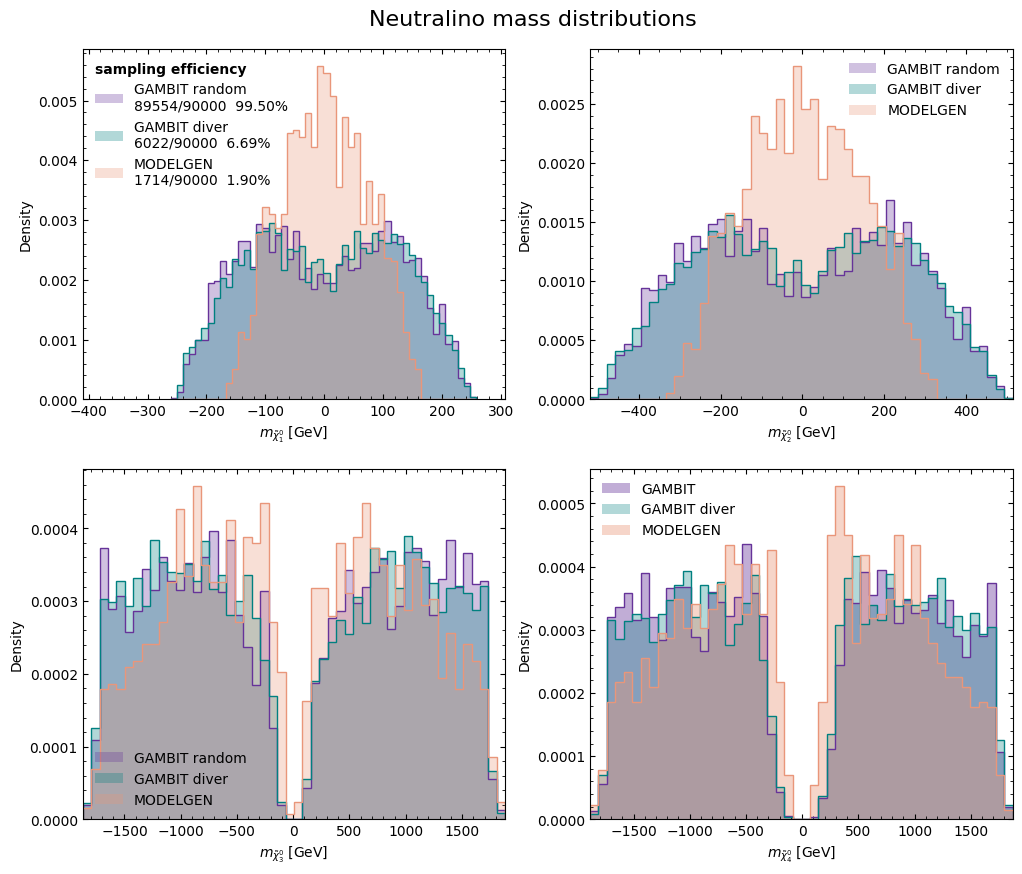

In [76]:
higgs_sector = {
    "parameter_list": [
        "SP_m_h",
        "SP_m_A",
        "SP_m_H",
        "SP_m_Hp"
    ],
    "labels": [
        "$m_h$ [GeV]",
        "$m_{A}$ [GeV]",
        "$m_{H}$ [GeV]",
        "$m_{H^+}$ [GeV]"
    ],
    "output_path": "higgs_sector_gm2",
    "title": "Higgs sector mass distributions"
}

neutralinos = {
    "parameter_list": [
        "SP_m_chi_10",
        "SP_m_chi_20",
        "SP_m_chi_30",
        "SP_m_chi_40"
    ],
    "labels": [
        "$m_{\\tilde{\\chi}_1^0}$ [GeV]",
        "$m_{\\tilde{\\chi}_2^0}$ [GeV]",
        "$m_{\\tilde{\\chi}_3^0}$ [GeV]",
        "$m_{\\tilde{\\chi}_4^0}$ [GeV]"
    ],
    "output_path": "neutralino_masses_gm2",
    "title": "Neutralino mass distributions"
}

sfermions = {
    "parameter_list": [
        "SP_m_mu_L",
        "SP_m_mu_R",
        "SP_m_t_1",
        "SP_m_t_2"
    ],
    "labels": [
        "$m_{\\tilde{\\mu}_L}$ [GeV]",
        "$m_{\\tilde{\\mu}_R}$ [GeV]",
        "$m_{\\tilde{t}_1}$ [GeV]",
        "$m_{\\tilde{t}_2}$ [GeV]"
    ],
    "output_path": "sfermion_masses_gm2",
    "title": "Sfermion mass distributions"
}

create_comparison_plots(**neutralinos)

In [63]:
# import pandas as pd
# input_par_list = ["IN_Ab", "IN_At", "IN_M_2", "IN_sgnMu", "IN_tanb", "IN_mHd2", "IN_mHu2", "IN_mbR"]
# gambit_columns = [parameter_lookup(par).split(";")[0].split("::")[-1] for par in input_par_list]
# input_parameters = {key: scan_gambit_diver[key][mask_gambit_diver] for key in scan_gambit_diver.keys() if "#MSSM7atQ_parameters @MSSM7atQ::primary_parameters::" in key and not key.endswith("_isvalid")}
# input_df = pd.DataFrame(data=input_parameters)
# input_df = input_df.drop(columns=["#MSSM7atQ_parameters @MSSM7atQ::primary_parameters::Qin"])
# input_df.columns = gambit_columns


# input_df.to_excel(f"samples/gambit_improved_pars_v{VERSION}.xlsx")
# input_df


In [64]:
# import yaml
# with open("yaml_files/gambit.yaml", "r") as yaml_file:
#     gambit_yaml = yaml.safe_load(yaml_file)

# gambit_yaml["Parameters"]["MSSM7atQ"] = {}
# for par in input_df.columns:
#     gambit_yaml["Parameters"]["MSSM7atQ"][par] = input_df[par].values.tolist()

# with open('yaml_files/gambit_improved.yaml', 'w') as f:
#     yaml.dump(gambit_yaml, f, sort_keys=False)

In [65]:
acceptance_range = [(25.1e-10 - 5.9e-10), (25.1e-10 + 5.9e-10)]
scan_err_gr = scan_gambit_random["#muon_gm2 @PrecisionBit::GM2C_SUSY::lower"][scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1]
scan_err_gd = scan_gambit_diver["#muon_gm2 @PrecisionBit::GM2C_SUSY::lower"][scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1]
scan_err_mg = scan_modelgen["GM2_Delta_gmuon"][scan_modelgen["GM2_gmuon"][:] != -1]

filter_par_pair = parameter_lookup("gmuon")
filter_gr = scan_gambit_random[filter_par_pair.split(";")[0]][scan_gambit_random[filter_par_pair.split(";")[0] + "_isvalid"][:] == 1]
filter_gd = scan_gambit_diver[filter_par_pair.split(";")[0]][scan_gambit_diver[filter_par_pair.split(";")[0] + "_isvalid"][:] == 1]
filter_mg = scan_modelgen[filter_par_pair.split(";")[1]][scan_modelgen[filter_par_pair.split(";")[1]][:] != -1]

mask_gr = (filter_gr > (acceptance_range[0] - scan_err_gr)) & (filter_gr < (acceptance_range[1] + scan_err_gr))
mask_gd = (filter_gd > (acceptance_range[0] - scan_err_gd)) & (filter_gd < (acceptance_range[1] + scan_err_gd))
mask_mg = (filter_mg > (acceptance_range[0] - scan_err_mg)) & (filter_mg < (acceptance_range[1] + scan_err_mg))

In [66]:
par1 = parameter_lookup("SP_m_h").split(";")
par2 = parameter_lookup("SP_m_chi_10").split(";")
par3 = parameter_lookup("SP_m_mu_L").split(";")
par4 = parameter_lookup("SP_m_t_1").split(";")

data_gambit_random1 = scan_gambit_random[par1[0]][scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1][mask_gr]
data_gambit_diver1 =  scan_gambit_diver[par1[0]][scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1][mask_gd]
data_modelgen1 = scan_modelgen[par1[1]][scan_modelgen["GM2_gmuon"][:] != -1][mask_mg]

data_gambit_random2 = scan_gambit_random[par2[0]][scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1][mask_gr]
data_gambit_diver2 =  scan_gambit_diver[par2[0]][scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1][mask_gd]
data_modelgen2 = scan_modelgen[par2[1]][scan_modelgen["GM2_gmuon"][:] != -1][mask_mg]   

data_gambit_random3 = scan_gambit_random[par3[0]][scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1][mask_gr]
data_gambit_diver3 =  scan_gambit_diver[par3[0]][scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1][mask_gd]
data_modelgen3 = scan_modelgen[par3[1]][scan_modelgen["GM2_gmuon"][:] != -1][mask_mg]

data_gambit_random4 = scan_gambit_random[par4[0]][scan_gambit_random["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1][mask_gr]
data_gambit_diver4 =  scan_gambit_diver[par4[0]][scan_gambit_diver["#lnL_gm2 @PrecisionBit::lnL_gm2_isvalid"][:] == 1][mask_gd]
data_modelgen4 = scan_modelgen[par4[1]][scan_modelgen["GM2_gmuon"][:] != -1][mask_mg]

sampl_eff_gambit1 =   f"GAMBIT random \n{np.sum(mask_gr)}/{len(mask_gambit_random)}  {(np.sum(mask_gr)/len(mask_gambit_random))*100:.2f}%"
sampl_eff_gambit_diver1 =  f"GAMBIT diver\n{np.sum(mask_gd)}/{len(mask_gambit_diver)}  {(np.sum(mask_gd)/len(mask_gambit_diver))*100:.2f}%"
sampl_eff_modelgen1 = f"MODELGEN\n{np.sum(mask_mg)}/{len(mask_modelgen)}  {(np.sum(mask_mg)/len(mask_modelgen))*100:.2f}%"



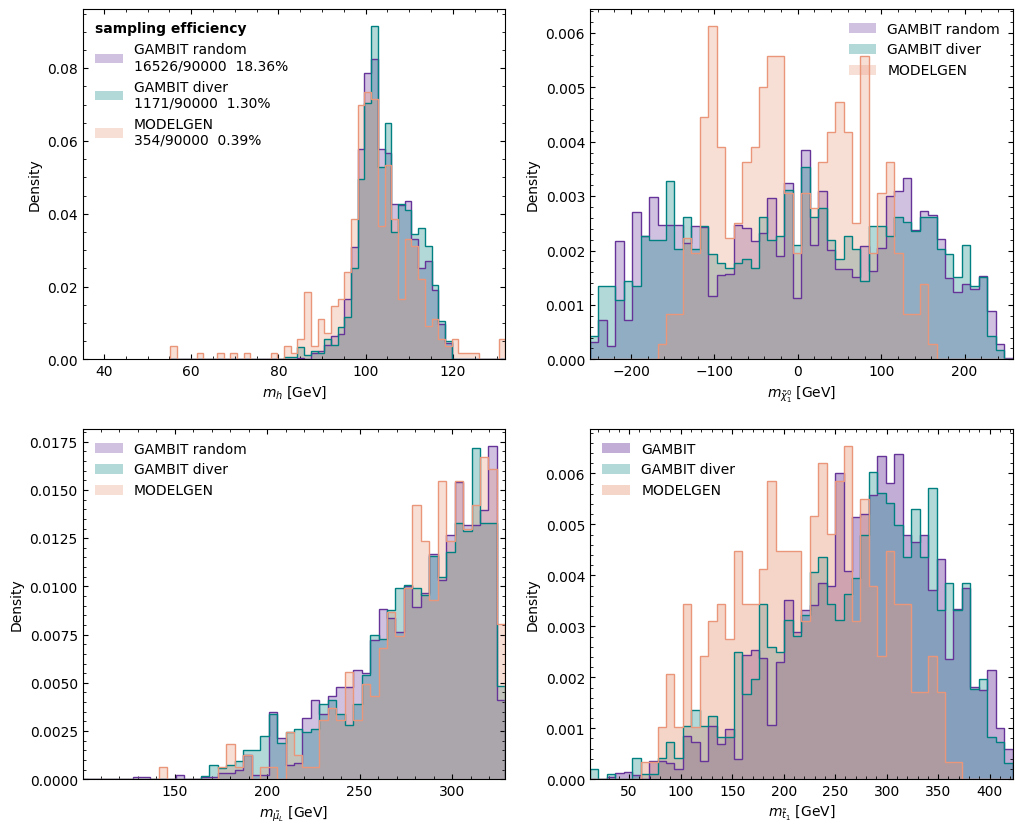

In [67]:
fig = plt.figure(figsize=(12,10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)

hist_range1 = (
        min([np.min(data_gambit_random1), np.min(data_modelgen1), np.min(data_gambit_diver1)]),
        max([np.max(data_gambit_random1), np.max(data_modelgen1), np.max(data_gambit_diver1)])
        )

hist_range2 = (
        min([np.min(data_gambit_random2), np.min(data_modelgen2), np.min(data_gambit_diver2)]),
        max([np.max(data_gambit_random2), np.max(data_modelgen2), np.max(data_gambit_diver2)])
        )

hist_range3 = (
        min([np.min(data_gambit_random3), np.min(data_modelgen3), np.min(data_gambit_diver3)]),
        max([np.max(data_gambit_random3), np.max(data_modelgen3), np.max(data_gambit_diver3)])
        )

hist_range4 = (
        min([np.min(data_gambit_random4), np.min(data_modelgen4), np.min(data_gambit_diver4)]),
        max([np.max(data_gambit_random4), np.max(data_modelgen4), np.max(data_gambit_diver4)])
        )


ax1.hist(data_gambit_random1, bins=50, range=hist_range1, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label=sampl_eff_gambit1)
ax1.hist(data_gambit_random1, bins=50, range=hist_range1, density=True, histtype='step', color='rebeccapurple')
ax1.hist(data_gambit_diver1, bins=50, range=hist_range1, density=True, alpha=0.3, histtype='stepfilled', color='teal', label=sampl_eff_gambit_diver1)
ax1.hist(data_gambit_diver1, bins=50, range=hist_range1, density=True, histtype='step', color='teal')
ax1.hist(data_modelgen1, bins=50, range=hist_range1, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label=sampl_eff_modelgen1)
ax1.hist(data_modelgen1, bins=50, range=hist_range1, density=True, histtype='step', color='darksalmon')
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)
leg = ax1.legend(frameon=False)
leg.set_title("sampling efficiency", prop={'weight': 'bold'})
leg._legend_box.align = "left"
ax1.set_xlim(hist_range1[0]-20, hist_range1[1])
ax1.set_ylabel("Density")
ax1.set_xlabel("$m_h$ [GeV]")

ax2.hist(data_gambit_random2, bins=50, range=hist_range2, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label="GAMBIT random")
ax2.hist(data_gambit_random2, bins=50, range=hist_range2, density=True, histtype='step', color='rebeccapurple')
ax2.hist(data_gambit_diver2, bins=50, range=hist_range2, density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
ax2.hist(data_gambit_diver2, bins=50, range=hist_range2, density=True, histtype='step', color='teal')
ax2.hist(data_modelgen2, bins=50, range=hist_range2, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax2.hist(data_modelgen2, bins=50, range=hist_range2, density=True, histtype='step', color='darksalmon')
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax2.legend(frameon=False)
ax2.set_xlim(hist_range2)
ax2.set_ylabel("Density")
ax2.set_xlabel("$m_{\\tilde{\\chi}_1^0}$ [GeV]")

ax3.hist(data_gambit_random3, bins=50, range=hist_range3, density=True, alpha=0.3, histtype='stepfilled', color='rebeccapurple', label="GAMBIT random")
ax3.hist(data_gambit_random3, bins=50, range=hist_range3, density=True, histtype='step', color='rebeccapurple')
ax3.hist(data_gambit_diver3, bins=50, range=hist_range3, density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
ax3.hist(data_gambit_diver3, bins=50, range=hist_range3, density=True, histtype='step', color='teal')
ax3.hist(data_modelgen3, bins=50, range=hist_range3, density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax3.hist(data_modelgen3, bins=50, range=hist_range3, density=True, histtype='step', color='darksalmon')
ax3.minorticks_on()
ax3.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax3.legend(frameon=False)
ax3.set_xlim(hist_range3)
ax3.set_ylabel("Density")
ax3.set_xlabel("$m_{\\tilde{\\mu}_L}$ [GeV]")

ax4.hist(data_gambit_random4, bins=50, range=hist_range4, density=True, alpha=0.4, histtype='stepfilled', color='rebeccapurple', label="GAMBIT")
ax4.hist(data_gambit_random4, bins=50, range=hist_range4, density=True, histtype='step', color='rebeccapurple')
ax4.hist(data_gambit_diver4, bins=50, range=hist_range4, density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
ax4.hist(data_gambit_diver4, bins=50, range=hist_range4, density=True, histtype='step', color='teal')
ax4.hist(data_modelgen4, bins=50, range=hist_range4, density=True, alpha=0.4, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax4.hist(data_modelgen4, bins=50, range=hist_range4, density=True, histtype='step', color='darksalmon')
ax4.minorticks_on()
ax4.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax4.legend(frameon=False)
ax4.set_xlim(hist_range4)
ax4.set_ylabel("Density")
ax4.set_xlabel("$m_{\\tilde{t}_1}$ [GeV]")


fig.savefig(f"plots/thesis_plots/accepted_histograms.png", dpi=1000)

plt.show()